# Linear Regression — Complete Guide (From Scratch to Scikit-Learn)

This notebook brings together the full Linear Regression journey in one place:

1. **Simple Linear Regression** — one input feature ($y = wx + b$). We build the
   prediction function, manually tune parameters, define the cost function, and
   implement **Gradient Descent** from scratch to learn the best fit automatically.
2. **Multiple Linear Regression** — many input features
   ($y = w_1x_1 + w_2x_2 + \dots + w_nx_n + b$), implemented in a vectorized way
   with NumPy.
3. **Scikit-Learn** — the industry-standard way using `LinearRegression` and
   `SGDRegressor`, compared against our from-scratch results.

The goal is intuition first (what the math is doing), then the practical tools.

## 0. Imports & Setup
We rely on three libraries throughout:
- **NumPy** for numerical arrays and fast math.
- **Matplotlib** for plotting.
- **Seaborn** for prettier statistical plots (built on top of Matplotlib).

In [1]:
import numpy as np                 # Handling numerical arrays
import matplotlib.pyplot as plt    # Creating plots
import seaborn as sns              # Prettier statistical plots (built on matplotlib)

# Set a clean default style for all our plots
sns.set_theme()

---
# Part 1 — Simple Linear Regression

A **simple** linear regression model maps a single input feature `X` to a target
`y` using a straight line:

$$ f(x) = wx + b $$

- $w$ (**weight**) controls the **slope** of the line.
- $b$ (**bias**) controls the **y-intercept** (shifts the line up/down).

Our job is to find the $w$ and $b$ that make the line fit the data as closely as
possible.

## 1.1 Setup Data
We define our input feature `X` (Years of Experience) and our target label `y`
(Salary, in thousands).

In [2]:
# X represents our 'Feature' (the data we use to make predictions)
X = np.array([1, 3, 4, 6, 7])    # Years of experience

# y represents our 'Target' (the value we want the model to learn to predict)
y = np.array([15, 35, 45, 65, 75])  # Salary in thousands

## 1.2 Visualize the Raw Data
Before modeling, we look at the data points to check whether a (linear)
relationship exists between experience and salary.

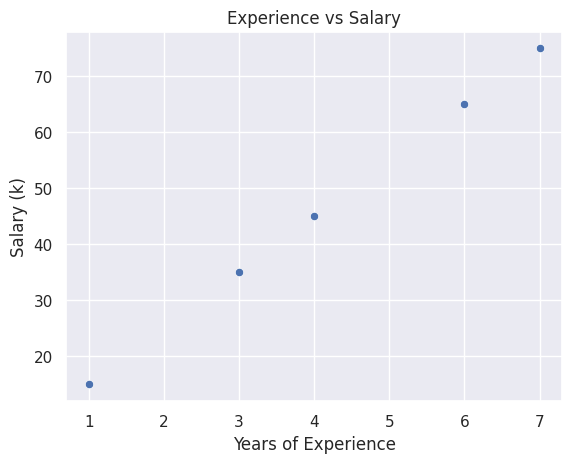

In [3]:
# Scatter plot to see the relationship between X and y
sns.scatterplot(x=X, y=y)
plt.xlabel("Years of Experience")
plt.ylabel("Salary (k)")
plt.title("Experience vs Salary")
plt.show()

## 1.3 The Prediction Function
The function below implements the linear formula $f(x) = wx + b$ for every data
point.

In [4]:
def make_prediction(X, y, w, b):
  """
  Calculates predictions using the linear regression formula: y = wx + b
  w: weight (slope)
  b: bias (intercept)
  """
  m = X.shape[0]            # Number of training examples
  pred_list = np.zeros((m,))  # Empty array to store our results

  for i in range(m):
    # Prediction for each specific data point
    pred_list[i] = w * X[i] + b

  return pred_list

## 1.4 Experimenting with Parameters
Now we test different values of `w` and `b` to see how well the resulting line
fits the data. This builds intuition for what $w$ and $b$ actually do, before we
automate the search.

Predictions (w=0, b=0): [0. 0. 0. 0. 0.]


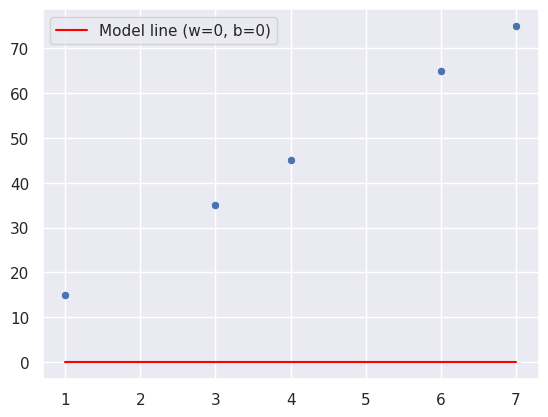

In [5]:
# Start with w=0 and b=0 (a flat line sitting at zero)
predictions = make_prediction(X, y, 0, 0)
print(f"Predictions (w=0, b=0): {predictions}")

# Visualize how this 'zero' model fits the data
sns.scatterplot(x=X, y=y)
plt.plot(X, predictions, color='red', label='Model line (w=0, b=0)')
plt.legend()
plt.show()

### Case 1: Minimal slope
Here $w=1, b=0$. The line is far below the data points — the slope is too small.

Predictions (w=1, b=0): [1. 3. 4. 6. 7.]


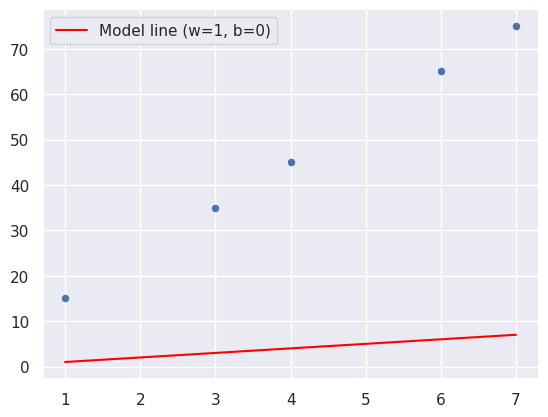

In [6]:
predictions = make_prediction(X, y, w=1, b=0)
print(f"Predictions (w=1, b=0): {predictions}")

sns.scatterplot(x=X, y=y)
plt.plot(X, predictions, color='red', label='Model line (w=1, b=0)')
plt.legend()
plt.show()

### Case 2: Increasing the slope
Using $w=5, b=3$ brings the line closer, but it's still not quite there.

Predictions (w=5, b=3): [ 8. 18. 23. 33. 38.]


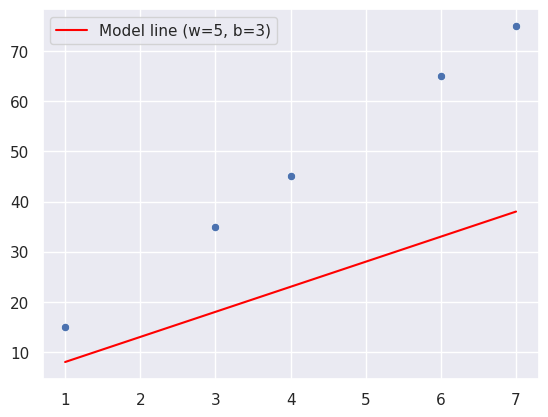

In [7]:
predictions = make_prediction(X, y, w=5, b=3)
print(f"Predictions (w=5, b=3): {predictions}")

sns.scatterplot(x=X, y=y)
plt.plot(X, predictions, color='red', label='Model line (w=5, b=3)')
plt.legend()
plt.show()

### Case 3: Finding a good fit by hand
With $w=10, b=5$, we see a much better alignment with the data points — in fact,
for this small dataset it's a perfect fit.

Predictions (w=10, b=5): [15. 35. 45. 65. 75.]


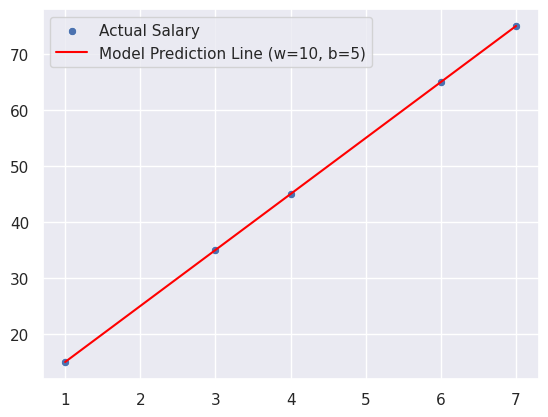

In [8]:
predictions = make_prediction(X, y, w=10, b=5)
print(f"Predictions (w=10, b=5): {predictions}")

# Plot the actual data points
sns.scatterplot(x=X, y=y, label='Actual Salary')
# Draw the model's prediction line
plt.plot(X, predictions, color='red', label='Model Prediction Line (w=10, b=5)')
plt.legend()
plt.show()

## 1.5 Cost Function (Mean Squared Error)
Eyeballing the line works for a tiny dataset, but we need a **number** that tells
us how good a fit is. That is the **cost** — here we use Mean Squared Error (MSE):

$$ J(w, b) = \frac{1}{2m} \sum_{i=1}^{m} \left( f(x^{(i)}) - y^{(i)} \right)^2 $$

A **lower cost means a better fit**. We divide by $2m$ instead of $m$ purely for
mathematical convenience — the $2$ cancels nicely when we take derivatives during
gradient descent.

In [9]:
def compute_cost(X, y, w, b):
  """Calculates the Mean Squared Error (MSE) to measure model accuracy."""
  m = X.shape[0]
  cost = 0.0

  for i in range(m):
    prediction = w * X[i] + b
    error = prediction - y[i]   # Difference between prediction and actual value
    error_squared = error ** 2
    cost = cost + error_squared

  # Divide by 2m for mathematical convenience in gradient calculations
  cost = cost / (2 * m)

  return cost

## 1.6 Visualizing the Cost
Let's attach the cost to a few candidate lines, then plot how the cost changes as
we sweep the weight $w$ (keeping $b$ fixed). The result is a convex, **U-shaped**
curve — and the lowest point of that "U" is exactly the $w$ we want.

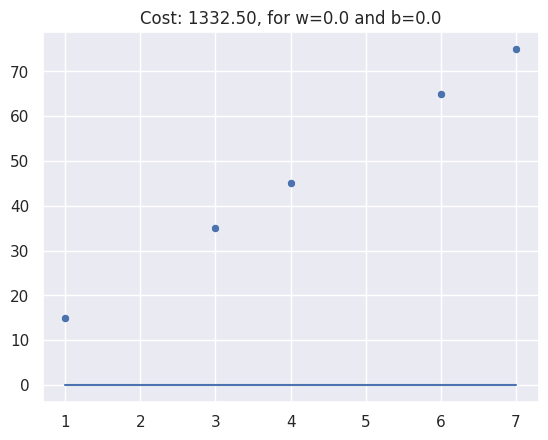

In [10]:
w = 0.0
b = 0.0

predictions = make_prediction(X, y, w=w, b=b)

sns.scatterplot(x=X, y=y)
plt.plot(X, predictions)
# The title shows the cost, helping us see how 'wrong' this line is
plt.title(f"Cost: {compute_cost(X, y, w=w, b=b):.2f}, for w={w} and b={b}")
plt.show()

[1. 3. 4. 6. 7.]


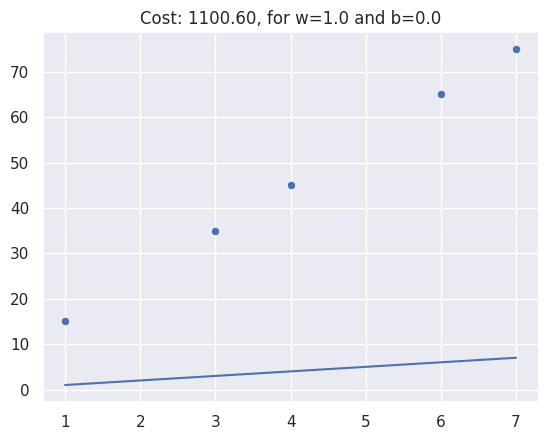

In [11]:
w = 1.0
b = 0.0

predictions = make_prediction(X, y, w=w, b=b)
print(predictions)

sns.scatterplot(x=X, y=y)
plt.plot(X, predictions)
plt.title(f"Cost: {compute_cost(X, y, w=w, b=b):.2f}, for w={w} and b={b}")
plt.show()

[ 3.  7.  9. 13. 15.]


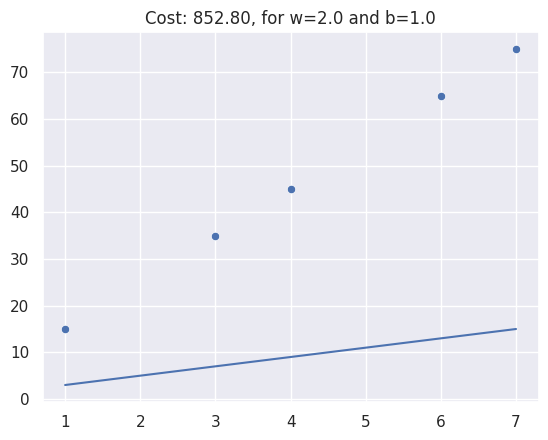

In [12]:
w = 2.0
b = 1.0

predictions = make_prediction(X, y, w=w, b=b)
print(predictions)

sns.scatterplot(x=X, y=y)
plt.plot(X, predictions)
plt.title(f"Cost: {compute_cost(X, y, w=w, b=b):.2f}, for w={w} and b={b}")
plt.show()

[15. 35. 45. 65. 75.]


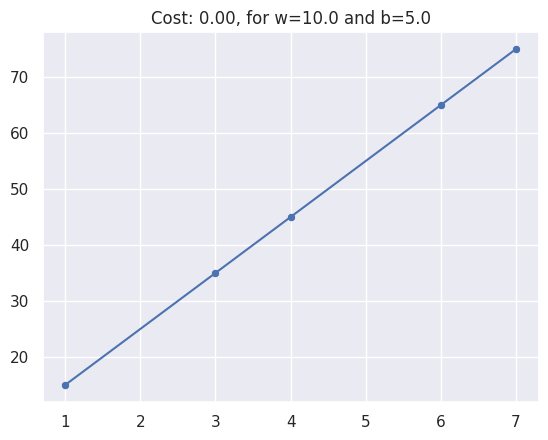

In [13]:
w = 10.0
b = 5.0

predictions = make_prediction(X, y, w=w, b=b)
print(predictions)

sns.scatterplot(x=X, y=y)
plt.plot(X, predictions)
plt.title(f"Cost: {compute_cost(X, y, w=w, b=b):.2f}, for w={w} and b={b}")
plt.show()

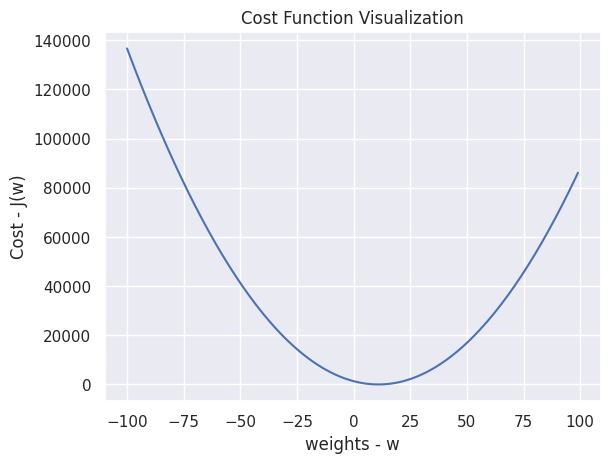

In [14]:
w_range = []
cost_history = []

# Loop through different weight values to see how each affects the cost
for i in range(-100, 100):
    cost_i = compute_cost(X, y, w=i, b=0)
    w_range.append(i)
    cost_history.append(cost_i)

# Plotting the Cost Function: the goal of ML is to find the bottom of this 'U'
plt.plot(w_range, cost_history)
plt.xlabel("weights - w")
plt.ylabel("Cost - J(w)")
plt.title("Cost Function Visualization")
plt.show()

## 1.7 Gradient Descent
Instead of guessing parameter values, we use the **gradient** (the slope of the
cost curve) to know which direction to nudge $w$ and $b$ so the cost goes *down*.

The partial derivatives of the cost are:

$$ \frac{\partial J}{\partial w} = \frac{1}{m}\sum_{i=1}^{m}(f(x^{(i)}) - y^{(i)})\,x^{(i)}
\qquad
\frac{\partial J}{\partial b} = \frac{1}{m}\sum_{i=1}^{m}(f(x^{(i)}) - y^{(i)}) $$

We then repeatedly update the parameters by a small step (the **learning rate**
$\alpha$) against the gradient:

$$ w := w - \alpha \frac{\partial J}{\partial w} \qquad b := b - \alpha \frac{\partial J}{\partial b} $$

In [15]:
def calculate_gradient(X, y, w, b):
  """Computes the gradient (direction to move) for w and b."""
  m = X.shape[0]
  dj_dw = 0.0   # Change needed for the weight
  dj_db = 0.0   # Change needed for the bias

  for i in range(m):
    prediction = w * X[i] + b
    error = prediction - y[i]
    # Multiply error by X[i] for the weight gradient
    dj_dw = dj_dw + (error * X[i])
    # The bias gradient is just the sum of errors
    dj_db = dj_db + error

  return dj_dw / m, dj_db / m

In [16]:
def gradient_descent(X, y, w_input, b_input, max_iter, alpha=0.01):
  """Automates the tuning of w and b to minimize the cost."""
  w = w_input
  b = b_input
  cost_memo = []
  iteration = []

  for i in range(max_iter):
    # 1. Calculate the gradients (the slope)
    dj_dw, dj_db = calculate_gradient(X, y, w, b)

    # 2. Update parameters by taking a small step (alpha) against the gradient
    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    # 3. Track progress by saving the cost
    cost = compute_cost(X, y, w, b)
    cost_memo.append(cost)
    iteration.append(i)

    # Log the status every 100 steps
    if i % 100 == 0:
      print(f"Iteration {i}: Cost {cost:0.4f}, w: {w:0.4f}, b: {b:0.4f}")

  return w, b, cost_memo, iteration

### Run Gradient Descent
We initialize $w$ and $b$ at 0 and let the algorithm find the best values.

In [17]:
# Run gradient descent and store the results in w_final and b_final
w_final, b_final, cost_memo, iter_list = gradient_descent(
    X, y, w_input=0, b_input=0, max_iter=10000, alpha=0.01
)

Iteration 0: Cost 790.3717, w: 2.4300, b: 0.4700
Iteration 100: Cost 0.6120, w: 10.4659, b: 2.5593
Iteration 200: Cost 0.4115, w: 10.3821, b: 2.9986
Iteration 300: Cost 0.2767, w: 10.3133, b: 3.3588
Iteration 400: Cost 0.1861, w: 10.2569, b: 3.6542
Iteration 500: Cost 0.1251, w: 10.2107, b: 3.8965
Iteration 600: Cost 0.0841, w: 10.1727, b: 4.0951
Iteration 700: Cost 0.0566, w: 10.1416, b: 4.2580
Iteration 800: Cost 0.0380, w: 10.1162, b: 4.3915
Iteration 900: Cost 0.0256, w: 10.0952, b: 4.5010
Iteration 1000: Cost 0.0172, w: 10.0781, b: 4.5909
Iteration 1100: Cost 0.0116, w: 10.0640, b: 4.6645
Iteration 1200: Cost 0.0078, w: 10.0525, b: 4.7249
Iteration 1300: Cost 0.0052, w: 10.0431, b: 4.7744
Iteration 1400: Cost 0.0035, w: 10.0353, b: 4.8150
Iteration 1500: Cost 0.0024, w: 10.0290, b: 4.8483
Iteration 1600: Cost 0.0016, w: 10.0237, b: 4.8756
Iteration 1700: Cost 0.0011, w: 10.0195, b: 4.8980
Iteration 1800: Cost 0.0007, w: 10.0160, b: 4.9164
Iteration 1900: Cost 0.0005, w: 10.0131, b

Notice how the gradients (`dj_dw`, `dj_db`) and the cost shrink toward zero over
the iterations. Once the algorithm **converges** to the minimum point of the cost
function, the updates become tiny and it effectively stops changing $w$ and $b$.

## 1.8 Final Results & Prediction
With the optimized parameters we can draw the best-fit line and predict the salary
for a brand-new input (e.g. someone with 2 years of experience).

Optimized w: 10.0000, b: 5.0000


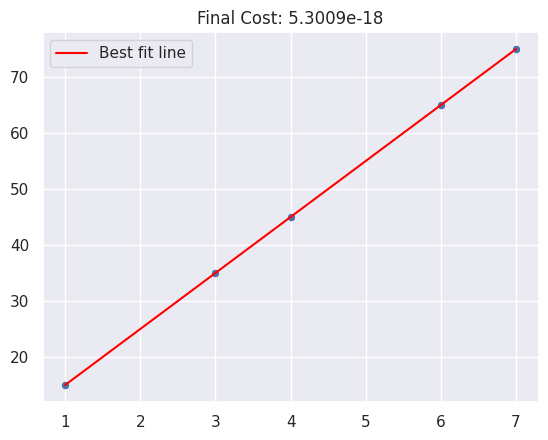

In [18]:
print(f"Optimized w: {w_final:0.4f}, b: {b_final:0.4f}")

# Final predictions based on optimized parameters
final_preds = make_prediction(X, y, w=w_final, b=b_final)

# Visualize the final best-fit line
sns.scatterplot(x=X, y=y)
plt.plot(X, final_preds, color='red', label='Best fit line')
plt.title(f"Final Cost: {compute_cost(X, y, w_final, b_final):0.4e}")
plt.legend()
plt.show()

In [19]:
# Example: predicting salary for someone with 2 years of experience
x_new = 2

# Using the formula f(x) = wx + b with our final calculated parameters
prediction = w_final * x_new + b_final
print(f"Predicted salary for {x_new} years of experience: {prediction:0.2f}k")

Predicted salary for 2 years of experience: 25.00k


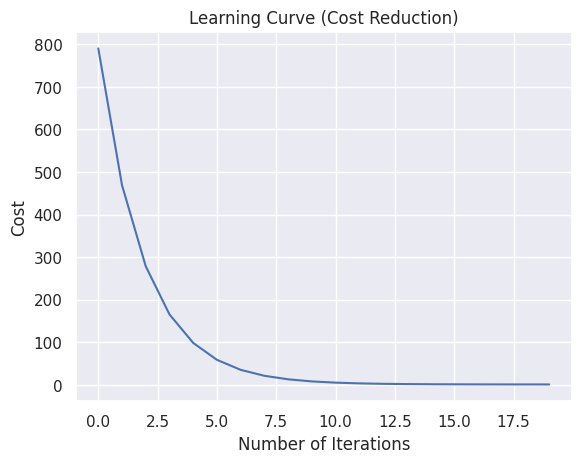

In [20]:
# Plot the cost over the first 20 iterations to see it dropping fast (learning curve)
plt.plot(iter_list[:20], cost_memo[:20])
plt.xlabel("Number of Iterations")
plt.ylabel("Cost")
plt.title("Learning Curve (Cost Reduction)")
plt.show()

---
# Part 2 — Multiple Linear Regression

Real problems rarely depend on a single feature. **Multiple** linear regression
extends the same idea to many input features:

$$ f(\mathbf{x}) = w_1x_1 + w_2x_2 + \dots + w_nx_n + b = \mathbf{w}\cdot\mathbf{x} + b $$

The structure is identical — prediction, cost, gradient descent — but now $\mathbf{w}$
is a **vector** of weights (one per feature) and we use the dot product.

## 2.1 Data Preparation
Each row of `X` is one person; each column is a feature:

| Column | Feature |
|--------|---------|
| 0 | Years of Experience |
| 1 | Problem-Solving (PS) Skill |
| 2 | Pause Time During Interview |
| 3 | GPA |

The target `y` is Salary. (This synthetic data was generated with true weights
`w = [5, 10, -2, 0.5]` and `b = 2.0`, so we have a known answer to check against.)

In [21]:
X = np.array([
    [1, 4, 1.5, 3.8],
    [3, 6, 1.0, 3.1],
    [4, 7, 0.8, 3.9],
    [5, 8, 0.4, 3.4],
    [7, 9, 0.2, 2.8]
])

# True parameters used to generate y:  w = [5, 10, -2, 0.5] , b = 2.0
y = np.array([45.9, 76.55, 92.35, 107.9, 128.])

Let's visualize each feature against the target to sanity-check the relationships.

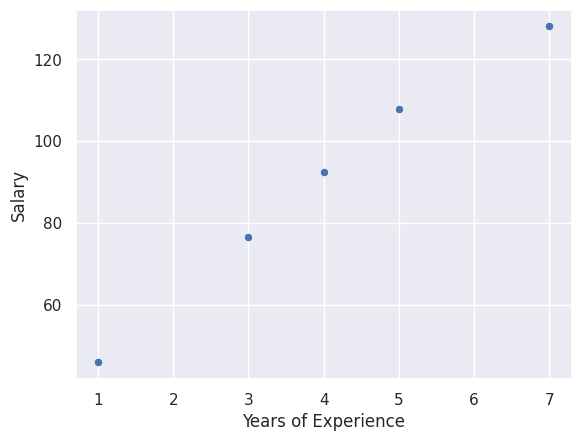

In [22]:
# Feature 0: Years of Experience
sns.scatterplot(x=X[:, 0:1].ravel(), y=y)
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

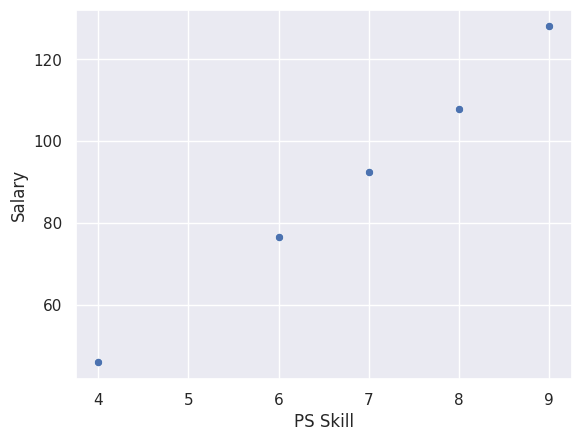

In [23]:
# Feature 1: Problem-Solving Skill
sns.scatterplot(x=X[:, 1:2].ravel(), y=y)
plt.xlabel("PS Skill")
plt.ylabel("Salary")
plt.show()

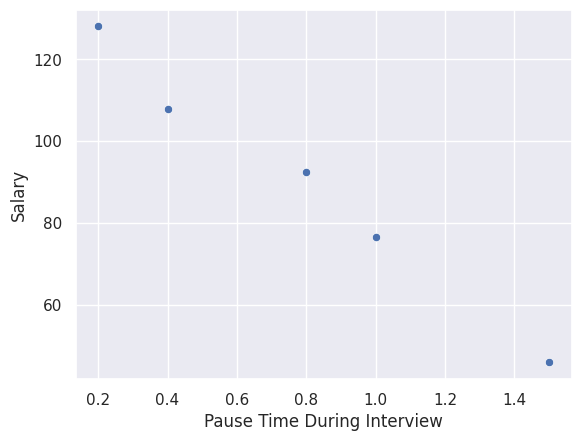

In [24]:
# Feature 2: Pause Time During Interview
sns.scatterplot(x=X[:, 2:3].ravel(), y=y)
plt.xlabel("Pause Time During Interview")
plt.ylabel("Salary")
plt.show()

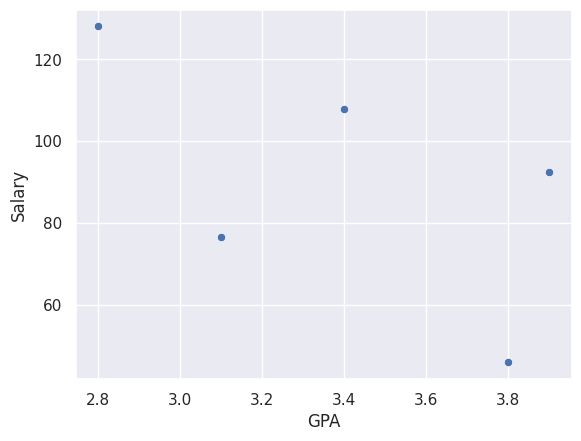

In [25]:
# Feature 3: GPA
sns.scatterplot(x=X[:, 3:].ravel(), y=y)
plt.xlabel("GPA")
plt.ylabel("Salary")
plt.show()

## 2.2 Manual Implementation (Vectorized)
We rebuild the same three components, now generalized to $n$ features:

1. **Prediction** — $f(\mathbf{x}) = \mathbf{w}\cdot\mathbf{x} + b$ (dot product).
2. **Cost** — Mean Squared Error, computed with vectorized NumPy operations.
3. **Gradient Descent** — adjusts the weight *vector* $\mathbf{w}$ and bias $b$.

### Prediction function
Note the signature changes to `(X, W, b)` and uses `np.dot(W, X[i])` so it works
for any number of features.

In [26]:
def make_prediction(X, W, b):
  """Calculates the model output: f(x) = W·x + b (for multiple features)."""
  m = X.shape[0]            # Number of training examples
  pred_list = np.zeros((m,))  # Initialize an array to store results

  for i in range(m):
    # X[i] = feature vector for one example, W = weights vector
    pred_list[i] = np.dot(W, X[i]) + b

  return pred_list

In [27]:
m = X.shape[0]   # number of examples
n = X.shape[1]   # number of features

# Quick sanity check with all-ones weights and bias = 1.0
W_init = np.ones((n,))
b_init = 1.0

make_prediction(X, W_init, b_init)

array([11.3, 14.1, 16.7, 17.8, 20. ])

### Cost function (vectorized)
Same MSE as before, but computed on whole arrays instead of a Python loop.

In [28]:
def compute_cost(X, y, W, b):
  """Calculates the Mean Squared Error (MSE) to measure model accuracy."""
  m = X.shape[0]

  pred_list = make_prediction(X, W, b)

  error = pred_list - y
  error_squared = error ** 2
  cost = np.sum(error_squared)

  # Divide by 2m for mathematical convenience in gradient calculations
  cost = cost / (2 * m)

  return cost

In [29]:
W_init = np.ones((n,))
b_init = 1.0
compute_cost(X, y, W_init, b_init)

np.float64(3060.2095)

### Gradient function
`dj_dw` is now a **vector** with one partial derivative per feature. For each
example we accumulate `error * X[i, j]` into the gradient of feature `j`.

In [30]:
def calculate_gradient(X, y, W, b):
  """Computes the gradient (direction to move) for the weight vector W and bias b."""
  m = X.shape[0]
  n = X.shape[1]

  dj_dw = np.zeros((n,))   # one gradient per feature (n features -> n weights)
  dj_db = 0.0              # Change needed for the bias

  for i in range(m):
    prediction = np.dot(W, X[i]) + b
    error = prediction - y[i]
    dj_db = dj_db + error

    for j in range(n):
      dj_dw[j] = dj_dw[j] + (error * X[i, j])

  return dj_dw / m, dj_db / m

In [31]:
W_init = np.ones((n,))
b_init = 1.0
calculate_gradient(X, y, W_init, b_init)

(array([-346.21 , -547.09 ,  -46.502, -245.77 ]), np.float64(-74.16))

### Gradient descent loop
Identical structure to the simple case; it just happens to update a vector `w`.

In [32]:
def gradient_descent(X, y, w_input, b_input, max_iter, alpha=0.01):
  """Automates the tuning of w (vector) and b to minimize the cost."""
  w = w_input
  b = b_input
  cost_memo = []
  iteration = []

  for i in range(max_iter):
    # 1. Calculate the gradients (the slope)
    dj_dw, dj_db = calculate_gradient(X, y, w, b)

    # 2. Update parameters by taking a small step (alpha) against the gradient
    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    # 3. Track progress by saving the cost
    cost = compute_cost(X, y, w, b)
    cost_memo.append(cost)
    iteration.append(i)

    # Log the status every 100 steps
    if i % 100 == 0:
      print(f"Iteration {i}: Cost {cost:0.4f}, dj_dw: {dj_dw}, dj_db: {dj_db}, w: {w}, b: {b:0.4f}")

  return w, b, cost_memo, iteration

### Training the Model
We initialize the weights to zero and run the gradient descent loop for many
iterations to find the optimal values.

In [33]:
W_init = np.zeros((n,))
b_init = 0.0

w_final, b_final, cost_memo, iter_list = gradient_descent(
    X, y, w_input=W_init, b_input=b_init, max_iter=100000, alpha=0.01
)

Iteration 0: Cost 188.4458, dj_dw: [-416.09  -660.91   -57.608 -299.43 ], dj_db: -90.14, w: [4.1609  6.6091  0.57608 2.9943 ], b: 0.9014
Iteration 100: Cost 0.1977, dj_dw: [-0.28972633 -0.05290958  0.24653403  0.43027154], dj_db: 0.08612436152810829, w: [ 6.8215041   8.3071171  -0.38008643  1.775159  ], b: 0.7104
Iteration 200: Cost 0.1303, dj_dw: [ 0.02982799 -0.05138487  0.04097921  0.06083368], dj_db: 0.007027042739039757, w: [ 6.88604616  8.35924356 -0.48209566  1.60468101], b: 0.6799
Iteration 300: Cost 0.1229, dj_dw: [ 0.05097646 -0.04994653  0.0258774   0.03389236], dj_db: 0.0014341624474738524, w: [ 6.84103994  8.40989801 -0.51257454  1.56262078], b: 0.6769
Iteration 400: Cost 0.1162, dj_dw: [ 0.05111217 -0.04855146  0.02422668  0.0311383 ], dj_db: 0.0010265453320059236, w: [ 6.7896808   8.45913669 -0.53741432  1.53048588], b: 0.6757
Iteration 500: Cost 0.1098, dj_dw: [ 0.04980317 -0.04719556  0.0235398   0.03011513], dj_db: 0.0009845325017124652, w: [ 6.7392106   8.50700022 -0

Iteration 7000: Cost 0.0031, dj_dw: [ 0.00800502 -0.00747695  0.00443134  0.00448077], dj_db: 0.00014070866893121093, w: [ 5.2532301   9.90848903 -1.3036129   0.62517488], b: 0.6407
Iteration 7100: Cost 0.0029, dj_dw: [ 0.0077831  -0.00726757  0.00432009  0.00435109], dj_db: 0.00013218203850016153, w: [ 5.24533767  9.91585975 -1.30798782  0.62075991], b: 0.6406
Iteration 7200: Cost 0.0028, dj_dw: [ 0.00756732 -0.00706403  0.00421169  0.00422515], dj_db: 0.00012379838564555712, w: [ 5.23766405  9.92302405 -1.31225293  0.61647273], b: 0.6405
Iteration 7300: Cost 0.0026, dj_dw: [ 0.00735753 -0.00686617  0.00410607  0.00410285], dj_db: 0.0001155563364463319, w: [ 5.23020316  9.9299877  -1.31641106  0.61230964], b: 0.6403
Iteration 7400: Cost 0.0025, dj_dw: [ 0.00715356 -0.00667382  0.00400317  0.00398408], dj_db: 0.00010745448447977424, w: [ 5.22294912  9.93675628 -1.32046494  0.60826705], b: 0.6402
Iteration 7500: Cost 0.0024, dj_dw: [ 0.00695523 -0.00648684  0.0039029   0.00386874], dj_d

Iteration 14000: Cost 0.0003, dj_dw: [ 0.00111663 -0.00100414  0.00080302  0.0005681 ], dj_db: -0.00019412298786676275, w: [ 5.0083662  10.13504419 -1.45015761  0.49234079], b: 0.6452
Iteration 14100: Cost 0.0003, dj_dw: [ 0.00108557 -0.00097519  0.00078509  0.00055146], dj_db: -0.00019623587871819836, w: [ 5.00726533 10.13603364 -1.45095154  0.49178114], b: 0.6454
Iteration 14200: Cost 0.0003, dj_dw: [ 0.00105537 -0.00094704  0.00076763  0.0005353 ], dj_db: -0.00019830228516894976, w: [ 5.00619509 10.13699455 -1.45172777  0.49123788], b: 0.6456
Iteration 14300: Cost 0.0003, dj_dw: [ 0.001026   -0.00091968  0.00075062  0.0005196 ], dj_db: -0.0002003231211460843, w: [ 5.00515462 10.13792771 -1.45248677  0.49071055], b: 0.6458
Iteration 14400: Cost 0.0003, dj_dw: [ 0.00099745 -0.00089308  0.00073404  0.00050437], dj_db: -0.00020229928539521324, w: [ 5.0041431  10.1388339  -1.45322898  0.49019867], b: 0.6460
Iteration 14500: Cost 0.0003, dj_dw: [ 0.00096969 -0.00086722  0.0007179   0.0004

Iteration 20900: Cost 0.0002, dj_dw: [ 1.55901610e-04 -1.12536097e-04  2.22903292e-04  6.93017978e-05], dj_db: -0.0002674515121981358, w: [ 4.97454629 10.16415586 -1.47983211  0.4758117 ], b: 0.6618
Iteration 21000: Cost 0.0002, dj_dw: [ 1.51415752e-04 -1.08410734e-04  2.19953068e-04  6.71183524e-05], dj_db: -0.0002678463491434968, w: [ 4.97439267 10.16426631 -1.48005351  0.47574351], b: 0.6621
Iteration 21100: Cost 0.0002, dj_dw: [ 1.47053852e-04 -1.04400263e-04  2.17078849e-04  6.49983844e-05], dj_db: -0.00026823061745204766, w: [ 4.97424346 10.16437268 -1.48027201  0.47567747], b: 0.6623
Iteration 21200: Cost 0.0002, dj_dw: [ 1.42812481e-04 -1.00501487e-04  2.14278664e-04  6.29400528e-05], dj_db: -0.00026860455445074647, w: [ 4.97409856 10.1644751  -1.48048767  0.47561351], b: 0.6626
Iteration 21300: Cost 0.0002, dj_dw: [ 1.38688308e-04 -9.67112984e-05  2.11550597e-04  6.09415704e-05], dj_db: -0.00026896839237906535, w: [ 4.97395784 10.16457368 -1.48070056  0.47555159], b: 0.6629
It

Iteration 27700: Cost 0.0002, dj_dw: [1.76907913e-05 1.37974713e-05 1.27508261e-04 4.36951052e-06], dj_db: -0.0002788689105869935, w: [ 4.97005365 10.16621276 -1.49084019  0.47400182], b: 0.6805
Iteration 27800: Cost 0.0002, dj_dw: [1.70231442e-05 1.43985191e-05 1.26997723e-04 4.07782684e-06], dj_db: -0.00027889767122246667, w: [ 4.9700363  10.16619865 -1.49096744  0.4739976 ], b: 0.6808
Iteration 27900: Cost 0.0002, dj_dw: [1.63739451e-05 1.49826758e-05 1.26499893e-04 3.79469143e-06], dj_db: -0.0002789242895332222, w: [ 4.9700196  10.16618396 -1.49109419  0.47399366], b: 0.6811
Iteration 28000: Cost 0.0002, dj_dw: [1.57426847e-05 1.55504109e-05 1.26014440e-04 3.51985547e-06], dj_db: -0.00027894881662007267, w: [ 4.97000355 10.16616869 -1.49122044  0.47399001], b: 0.6813
Iteration 28100: Cost 0.0002, dj_dw: [1.51288680e-05 1.61021804e-05 1.25541042e-04 3.25307728e-06], dj_db: -0.0002789713024185403, w: [ 4.96998812 10.16615286 -1.49134622  0.47398662], b: 0.6816
Iteration 28200: Cost 0

...

Iteration 68300: Cost 0.0002, dj_dw: [-6.04780195e-06  3.27742506e-05  9.97907100e-05 -5.16830110e-06], dj_db: -0.00025899366875989924, w: [ 4.97174883 10.15309224 -1.53387164  0.47585829], b: 0.7902
Iteration 68400: Cost 0.0002, dj_dw: [-6.04651570e-06  3.27672419e-05  9.97693389e-05 -5.16719603e-06], dj_db: -0.0002589382311896316, w: [ 4.97175487 10.15305947 -1.53397142  0.47586346], b: 0.7905
Iteration 68500: Cost 0.0002, dj_dw: [-6.04522951e-06  3.27602344e-05  9.97479728e-05 -5.16609115e-06], dj_db: -0.00025888280541721544, w: [ 4.97176092 10.15302671 -1.53407118  0.47586863], b: 0.7907
Iteration 68600: Cost 0.0002, dj_dw: [-6.04394328e-06  3.27532285e-05  9.97266114e-05 -5.16498639e-06], dj_db: -0.00025882739141707133, w: [ 4.97176696 10.15299395 -1.53417092  0.47587379], b: 0.7910
Iteration 68700: Cost 0.0002, dj_dw: [-6.04265717e-06  3.27462237e-05  9.97052549e-05 -5.16388190e-06], dj_db: -0.00025877198923325296, w: [ 4.97177301 10.1529612  -1.53427063  0.47587896], b: 0.7913
I

Iteration 75200: Cost 0.0002, dj_dw: [-5.95937907e-06  3.22938917e-05  9.83271524e-05 -5.09255116e-06], dj_db: -0.0002551960854560775, w: [ 4.97216307 10.15084743 -1.54070657  0.47621228], b: 0.8080
Iteration 75300: Cost 0.0002, dj_dw: [-5.95810465e-06  3.22869799e-05  9.83061029e-05 -5.09146116e-06], dj_db: -0.00025514145855254355, w: [ 4.97216903 10.15081514 -1.54080489  0.47621738], b: 0.8082
Iteration 75400: Cost 0.0002, dj_dw: [-5.95683046e-06  3.22800696e-05  9.82850580e-05 -5.09037142e-06], dj_db: -0.0002550868433331743, w: [ 4.97217499 10.15078286 -1.54090318  0.47622247], b: 0.8085
Iteration 75500: Cost 0.0002, dj_dw: [-5.95555651e-06  3.22731606e-05  9.82640176e-05 -5.08928188e-06], dj_db: -0.00025503223979086445, w: [ 4.97218094 10.15075058 -1.54100146  0.47622756], b: 0.8087
Iteration 75600: Cost 0.0002, dj_dw: [-5.95428278e-06  3.22662532e-05  9.82429818e-05 -5.08819257e-06], dj_db: -0.00025497764792135056, w: [ 4.9721869  10.15071831 -1.54109971  0.47623265], b: 0.8090
It

Iteration 82100: Cost 0.0002, dj_dw: [-5.87203385e-06  3.18203927e-05  9.68853158e-05 -5.01788143e-06], dj_db: -0.00025145411534026606, w: [ 4.97257125 10.14863553 -1.54744127  0.47656109], b: 0.8254
Iteration 82200: Cost 0.0002, dj_dw: [-5.87077710e-06  3.18135813e-05  9.68645763e-05 -5.01680733e-06], dj_db: -0.0002514002890862344, w: [ 4.97257712 10.14860371 -1.54753815  0.47656611], b: 0.8257
Iteration 82300: Cost 0.0002, dj_dw: [-5.86952063e-06  3.18067713e-05  9.68438412e-05 -5.01573349e-06], dj_db: -0.00025134647435862687, w: [ 4.97258299 10.1485719  -1.547635    0.47657112], b: 0.8259
Iteration 82400: Cost 0.0002, dj_dw: [-5.86826434e-06  3.17999630e-05  9.68231106e-05 -5.01465980e-06], dj_db: -0.0002512926711276009, w: [ 4.97258886 10.1485401  -1.54773184  0.47657614], b: 0.8262
Iteration 82500: Cost 0.0002, dj_dw: [-5.86700834e-06  3.17931560e-05  9.68023844e-05 -5.01358637e-06], dj_db: -0.000251238879420157, w: [ 4.97259472 10.1485083  -1.54782865  0.47658115], b: 0.8264
Iter

Iteration 89100: Cost 0.0002, dj_dw: [-5.78469844e-06  3.13470979e-05  9.54442270e-05 -4.94324526e-06], dj_db: -0.0002477139657628413, w: [ 4.97297922 10.14642471 -1.55417267  0.47690972], b: 0.8429
Iteration 89200: Cost 0.0002, dj_dw: [-5.78346024e-06  3.13403876e-05  9.54237961e-05 -4.94218714e-06], dj_db: -0.00024766094007020454, w: [ 4.97298501 10.14639337 -1.55426811  0.47691466], b: 0.8432
Iteration 89300: Cost 0.0002, dj_dw: [-5.78222228e-06  3.13336789e-05  9.54033696e-05 -4.94112922e-06], dj_db: -0.00024760792572067205, w: [ 4.97299079 10.14636203 -1.55436352  0.47691961], b: 0.8434
Iteration 89400: Cost 0.0002, dj_dw: [-5.78098455e-06  3.13269717e-05  9.53829475e-05 -4.94007152e-06], dj_db: -0.0002475549227156648, w: [ 4.97299657 10.1463307  -1.55445891  0.47692455], b: 0.8437
Iteration 89500: Cost 0.0002, dj_dw: [-5.77974707e-06  3.13202659e-05  9.53625298e-05 -4.93901403e-06], dj_db: -0.0002475019310537618, w: [ 4.97300235 10.14629938 -1.55455429  0.47692949], b: 0.8439
Ite

Iteration 96000: Cost 0.0002, dj_dw: [-5.69987724e-06  3.08874507e-05  9.40447108e-05 -4.87076160e-06], dj_db: -0.00024408169380762956, w: [ 4.97337543 10.14427766 -1.56070992  0.4772483 ], b: 0.8599
Iteration 96100: Cost 0.0002, dj_dw: [-5.69865717e-06  3.08808388e-05  9.40245795e-05 -4.86971900e-06], dj_db: -0.00024402944563348684, w: [ 4.97338113 10.14424678 -1.56080395  0.47725317], b: 0.8601
Iteration 96200: Cost 0.0002, dj_dw: [-5.69743733e-06  3.08742285e-05  9.40044526e-05 -4.86867659e-06], dj_db: -0.00024397720863333916, w: [ 4.97338683 10.1442159  -1.56089796  0.47725804], b: 0.8604
Iteration 96300: Cost 0.0002, dj_dw: [-5.69621774e-06  3.08676195e-05  9.39843300e-05 -4.86763441e-06], dj_db: -0.00024392498281571305, w: [ 4.97339253 10.14418503 -1.56099196  0.47726291], b: 0.8606
Iteration 96400: Cost 0.0002, dj_dw: [-5.69499838e-06  3.08610121e-05  9.39642117e-05 -4.86659241e-06], dj_db: -0.0002438727681649766, w: [ 4.97339822 10.14415416 -1.56108593  0.47726777], b: 0.8609
I

In [34]:
print(w_final)
print(b_final)

# Recall the true parameters:  w = [5, 10, -2, 0.5] , b = 2.0
# Our learned values should be close to these.

[ 4.9736024  10.14304775 -1.56445471  0.47744225]
0.8695947679497865


### Making Predictions
With trained weights we can predict the salary for a new person given their
features `[experience, PS skill, pause time, GPA]`.

In [35]:
X_test = [2, 10, 1.5, 3.8]

prediction_of_new_data = (
    w_final[0] * X_test[0]
    + w_final[1] * X_test[1]
    + w_final[2] * X_test[2]
    + w_final[3] * X_test[3]
    + b_final
)

print(prediction_of_new_data)

111.71487549666959


---
# Part 3 — Linear Regression using Scikit-Learn

Building from scratch is great for understanding, but in practice we use
`scikit-learn`: it's faster, well-tested, and handles the math for us. Here we
fit the **same data** with two estimators and compare against our from-scratch
result (true `w = [5, 10, -2, 0.5]`, `b = 2.0`).

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor

## 3.1 `LinearRegression`
This solves the regression analytically (closed-form), so it recovers the true
parameters almost exactly.

In [37]:
model1 = LinearRegression()

# Learning (fitting) the model
model1.fit(X, y)

weights = model1.coef_
bias = model1.intercept_

print(weights)
print(bias)

[ 5.  10.  -2.   0.5]
2.000000000000199


## 3.2 `SGDRegressor`
`SGDRegressor` implements **Stochastic Gradient Descent** — the same idea we coded
by hand. It's especially useful for very large datasets where the closed-form
`LinearRegression` would be too slow. Because it's an iterative, stochastic method,
its results are approximate and sensitive to settings like the learning rate and
number of iterations.

In [38]:
model2 = SGDRegressor(penalty=None, max_iter=10000000, learning_rate="constant")

model2.fit(X, y)

weights = model2.coef_
bias = model2.intercept_

print(weights)
print(bias)

[ 6.45700272  8.81066129 -0.69316343  1.23132115]
[0.70700969]


---
# Part 4 — Where It's Used, Why It Matters & How to Tune It

We've now built Linear Regression from scratch and confirmed it with
scikit-learn. Two questions usually come up next: **"Where would I actually
use this?"** and **"What knobs can I turn to make it work better?"** This
part answers both, in plain language.

## 4.1 Where Is Linear Regression Used? (Real-World Applications)

Anywhere you want to predict a **number** from one or more inputs, and the
relationship is roughly a straight line (or close enough to be useful),
linear regression is a natural first choice:

| Domain | Example |
|--------|---------|
| 🏠 Real Estate | Predicting house price from size, location, number of rooms |
| 💰 Finance | Credit-risk scoring, forecasting revenue or expenses |
| 📈 Sales & Marketing | Predicting sales from advertising spend |
| 🏥 Healthcare | Estimating a dosage-response relationship, or a health metric from patient stats |
| 🌾 Agriculture | Predicting crop yield from rainfall, fertilizer, temperature |
| ⚡ Energy | Forecasting electricity demand from temperature and time of day |
| 🎓 Education / HR | Predicting salary or exam score from experience and skills — exactly our Part 1 & 2 datasets! |
| 🚚 Logistics | Estimating delivery time from distance and traffic |

It's also used constantly as a **baseline**: before reaching for a complex
model (random forest, neural network), practitioners fit a linear
regression first just to know *"how good is the simplest possible model?"*
If the fancy model can't beat this baseline by much, the extra complexity
usually isn't worth it.

## 4.2 Why Linear Regression? (Why Bother, When Fancier Models Exist)

| Reason | Plain English |
|--------|---------------|
| **Interpretable** | Each weight tells you exactly how much a feature matters. `w = 5` literally means *"+1 year of experience → +5k salary."* Neural networks can't tell you this directly. |
| **Fast** | Training is close to instant, even the closed-form solution scales well. |
| **Low data hunger** | Works reasonably well even on a handful of points (Part 1's dataset had only 5!). Deep learning needs far more. |
| **A strong baseline** | If a complicated model can't clearly beat plain linear regression, the added complexity isn't paying for itself. |
| **The foundation of other models** | Logistic Regression, Ridge, Lasso — and even a single neuron in a neural network — are all linear regression with a small twist. |
| **Statistically well understood** | Over a century of statistics gives us confidence intervals and significance tests — a formal way to ask *"does this feature actually matter?"*, not just a prediction number. |

## 4.3 Parameters vs. Hyperparameters — the Key Distinction

This trips up a lot of beginners, so let's make it concrete using code
you've already run in this notebook.

| | Learned automatically? | Example from this notebook |
|---|---|---|
| **Parameter** | ✅ Yes — the model finds these during training | `w`, `b` — what `gradient_descent()` returns |
| **Hyperparameter** | ❌ No — *you* choose these before training starts | `alpha` and `max_iter` — the settings you passed **into** `gradient_descent(X, y, w_input=0, b_input=0, max_iter=10000, alpha=0.01)` back in Part 1 |

**In short:** parameters are the *answer*; hyperparameters are the *settings
you use to search for the answer*. Choosing good hyperparameters is the
difference between a model that trains in seconds and one that never
converges.

## 4.4 Hyperparameter #1 — Learning Rate ($\alpha$)

This is the single most important hyperparameter in gradient descent, and
you already met it in Part 1.7. Recall the update rule:

$$ w := w - \alpha \frac{\partial J}{\partial w} $$

$\alpha$ controls **how big a step** we take on every iteration:

- **Too small** → each step barely moves `w` and `b`. The model *will*
  eventually reach the best fit, but wastes many iterations getting there.
- **Too large** → each step overshoots the minimum. Instead of settling
  into the bottom of the cost bowl, the parameters bounce further out
  each time, and the cost **grows without bound** (diverges) instead of
  shrinking.
- **Just right** → cost drops quickly and smoothly toward the minimum.

Let's see all three side by side, using the exact same dataset and update
rule from Part 1 — only `alpha` changes:

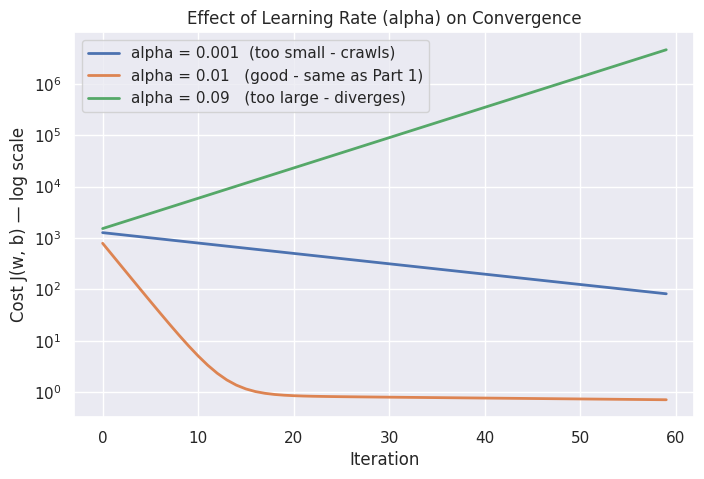

In [39]:
def compute_cost_1d(X, y, w, b):
    m = X.shape[0]
    predictions = w * X + b
    return np.sum((predictions - y) ** 2) / (2 * m)

def gradient_descent_track_cost(X, y, alpha, max_iter=60):
    """Same update rule as Part 1's gradient_descent(), just tracking cost."""
    w, b = 0.0, 0.0
    m = X.shape[0]
    cost_history = []
    for i in range(max_iter):
        predictions = w * X + b
        error = predictions - y
        dj_dw = np.sum(error * X) / m
        dj_db = np.sum(error) / m
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        cost_history.append(compute_cost_1d(X, y, w, b))
    return cost_history

# Reusing Part 1's dataset (Years of Experience -> Salary)
X_demo = np.array([1, 3, 4, 6, 7])
y_demo = np.array([15, 35, 45, 65, 75])

learning_rates = {
    "alpha = 0.001  (too small - crawls)":    0.001,
    "alpha = 0.01   (good - same as Part 1)": 0.01,
    "alpha = 0.09   (too large - diverges)":  0.09,
}

plt.figure(figsize=(8, 5))
for label, alpha in learning_rates.items():
    cost_history = gradient_descent_track_cost(X_demo, y_demo, alpha, max_iter=60)
    plt.plot(cost_history, label=label, linewidth=2)

plt.xlabel("Iteration")
plt.ylabel("Cost J(w, b) — log scale")
plt.title("Effect of Learning Rate (alpha) on Convergence")
plt.legend()
plt.yscale("log")
plt.show()

Notice the pattern:
- **$\alpha = 0.001$** is still high after 60 iterations — heading the
  right way, just far too slowly.
- **$\alpha = 0.01$** — the exact value used back in Part 1 — drops toward
  zero fast and stays low. This is why it was chosen.
- **$\alpha = 0.09$** shoots *upward*, off the scale. The steps are so
  large that every update overshoots and makes things worse.

**Rule of thumb:** if the cost is decreasing but slowly, try increasing
$\alpha$ (e.g. 3x). If the cost is oscillating or exploding, decrease it
(e.g. 10x). Repeat until you find the largest $\alpha$ that still converges
smoothly — that reaches the answer fastest without diverging.

## 4.5 Hyperparameter #2 — Number of Iterations (`max_iter`)

The other knob in Part 1's `gradient_descent()`. It decides how many update
steps we take before stopping.

- **Too few** → we stop before reaching the bottom of the cost bowl (the
  model was still improving when we quit — a form of underfitting).
- **Too many** → wasted computation once the cost has flattened out. For
  linear regression's convex, bowl-shaped cost this is harmless, just
  slow — unlike in neural networks, extra iterations here can't cause
  *overfitting*, since there's only one minimum to find.
- **A common alternative**: instead of a fixed count, stop automatically
  once the cost stops improving by more than a tiny threshold between
  steps — this is exactly what scikit-learn's `tol` parameter does, below.
- **One more small one — initial values of `w` and `b`** (`w_input`, `b_input`
  in Part 1's function signature): technically a hyperparameter too, since
  you choose it before training starts. For linear regression specifically
  it barely matters *where* you start (the cost bowl is convex — one lowest
  point, reachable from anywhere), only *how many iterations* it takes to
  get there. This stops being true for non-convex problems like neural
  networks, where the starting point can matter a great deal.

## 4.6 Hyperparameters in Scikit-Learn's `SGDRegressor`

`SGDRegressor` is our Part 1/2 gradient descent, made production-ready — so
it exposes several more hyperparameters:

| Hyperparameter | What it controls | Why you'd tune it |
|---|---|---|
| `alpha` | **Regularization strength** (a different `alpha` than the learning rate, despite the same symbol!) | Higher → simpler model, weights shrink toward zero, less overfitting. Lower → fits the training data more closely. |
| `penalty` | Type of regularization: `'l2'`, `'l1'`, `'elasticnet'`, or `None` | `l2` shrinks weights smoothly; `l1` can push some weights to *exactly* zero (automatic feature selection); `elasticnet` blends both. |
| `learning_rate` | The step-size **schedule**: `'constant'`, `'optimal'`, `'invscaling'`, `'adaptive'` | `'constant'` behaves like our Part 1 code; the others shrink the step size over time, often converging more reliably. |
| `eta0` | The initial learning rate (used when `learning_rate` isn't `'optimal'`) | Same role as `alpha` in Part 1 — too high diverges, too low crawls. |
| `max_iter` | Maximum number of passes over the data | Same idea as Part 1's `max_iter`. |
| `tol` | Stop early once improvement between iterations is smaller than this | Saves time — no point training once the model has effectively converged. |

### `alpha` (regularization) in action
Let's fit the same Part 2/3 dataset with three regularization strengths and
watch the weights shrink:

In [40]:
X_multi = np.array([
    [1, 4, 1.5, 3.8],
    [3, 6, 1.0, 3.1],
    [4, 7, 0.8, 3.9],
    [5, 8, 0.4, 3.4],
    [7, 9, 0.2, 2.8]
])
y_multi = np.array([45.9, 76.55, 92.35, 107.9, 128.])

# Same data as Part 2/3 - only the regularization strength (alpha) changes
for alpha in [0.0001, 1.0, 100.0]:
    model = SGDRegressor(penalty="l2", alpha=alpha, max_iter=10000,
                          learning_rate="constant", eta0=0.01, random_state=42)
    model.fit(X_multi, y_multi)
    print(f"alpha={alpha:<8} -> weights={np.round(model.coef_, 2)}  "
          f"bias={round(model.intercept_[0], 2):<6}  ||w||={np.linalg.norm(model.coef_):.2f}")

alpha=0.0001   -> weights=[ 6.72  8.41 -0.68  1.6 ]  bias=0.64    ||w||=10.91
alpha=1.0      -> weights=[ 6.52  8.06 -0.38  1.78]  bias=3.95    ||w||=10.53
alpha=100.0    -> weights=[-0.84 -1.08 -0.02 -0.34]  bias=75.28   ||w||=1.41


As `alpha` climbs from `0.0001` to `100`, the size of the weight vector
(`||w||`) keeps shrinking — the model is pushed toward a flatter, simpler
line, even though it fits the training data a little worse. This trade-off
(fit vs. simplicity) is exactly what a regularization hyperparameter is
for.

## 4.7 Hyperparameters in Scikit-Learn's `LinearRegression`

By contrast, `LinearRegression` barely has any hyperparameters to tune —
and that's not a limitation, it's a consequence of *how* it solves the
problem.

| Hyperparameter | What it controls | Why you'd tune it |
|---|---|---|
| `fit_intercept` | Whether to compute `b` at all (default `True`) | Set `False` only if you know the line must pass through the origin. |
| `positive` | Force all weights to be ≥ 0 | Useful when negative coefficients would make no real-world sense. |
| `n_jobs` | Parallelization for large multi-target problems | A speed knob, not a modeling knob. |

**Why so few?** `LinearRegression` doesn't search step-by-step like
gradient descent — it solves the cost function directly with a closed-form
formula (the Normal Equation). There's no "step size" or "iteration count"
because there's no searching to do; the answer is computed in one shot.
This is also *why* `SGDRegressor` exists: as data grows very large, the
closed-form computation gets expensive, so we trade the exact-in-one-shot
approach for an iterative one — and pick up all those extra hyperparameters
as the price of that trade.

## 4.8 Quick Reference — Which Hyperparameter Matters Most?

| Priority | Hyperparameter | When it matters |
|---|---|---|
| 🥇 1st | **Learning rate** (`alpha` in Part 1 / `eta0` in `SGDRegressor`) | Always, for any gradient-descent-based training. Get this wrong and nothing else matters. |
| 🥈 2nd | **Regularization strength** (`alpha` in `SGDRegressor`) | When you have many features, noisy data, or the model overfits. |
| 🥉 3rd | **`max_iter` / `tol`** | When training is clearly unfinished (cost still dropping) or wastefully long (cost long flat). |
| Rarely | `fit_intercept`, `positive`, `penalty` type, `n_jobs` | Only in specific situations dictated by your data or domain knowledge. |

**One-line summary:** spend most of your tuning effort on the **learning
rate** when using gradient descent, and on **regularization strength** when
you're worried about overfitting. Everything else is a minor adjustment.

## 4.9 The Complete List (Every Remaining Hyperparameter, For Reference)

Sections 4.4–4.7 covered the hyperparameters people actually reach for in
practice. To fully answer "*is that ALL of them?*" — no, scikit-learn
exposes more. Here is every remaining one, straight from the installed
library (`inspect.signature`), so nothing is left out:

### `SGDRegressor` — the rest of the list

| Hyperparameter | Default | What it controls |
|---|---|---|
| `loss` | `'squared_error'` | The cost function itself. `'squared_error'` = MSE (what this whole notebook uses). `'huber'` is less sensitive to outliers; `'epsilon_insensitive'` / `'squared_epsilon_insensitive'` ignore small errors entirely (SVM-style regression). |
| `l1_ratio` | `0.15` | Only used when `penalty='elasticnet'` — the mix between L1 and L2 (`0`=pure L2, `1`=pure L1). |
| `fit_intercept` | `True` | Same idea as in `LinearRegression` — whether to learn a bias `b` at all. |
| `shuffle` | `True` | Reshuffle the training data after every pass, so stochastic gradient descent doesn't see the same order every epoch. |
| `epsilon` | `0.1` | The margin of tolerance, only used by the `huber` / `epsilon_insensitive` losses. |
| `power_t` | `0.25` | Only used when `learning_rate='invscaling'` — controls how fast the step size shrinks over time. |
| `early_stopping` | `False` | If `True`, stop once a held-out validation score stops improving. |
| `validation_fraction` | `0.1` | Slice of training data set aside for that early-stopping check. |
| `n_iter_no_change` | `5` | Epochs of no improvement to wait before stopping (used by `tol` / `early_stopping`). |
| `warm_start` | `False` | If `True`, a new `.fit()` call continues from the previous solution instead of restarting — useful for online/incremental learning. |
| `average` | `False` | If set, returns the *average* of the weights seen across iterations instead of the last one — sometimes more stable. |
| `random_state` | `None` | Seeds the shuffling/randomness for reproducible runs. Doesn't change *what* is learned, just makes reruns repeatable. |
| `verbose` | `0` | How much progress logging to print — a debugging aid, not a modeling choice. |

### `LinearRegression` — the rest of the list

| Hyperparameter | Default | What it controls |
|---|---|---|
| `tol` | `1e-06` | Convergence tolerance for the internal solver on very large/ill-conditioned data. Almost never touched. |
| `copy_X` | `True` | Whether to copy `X` before fitting or modify it in place — a memory/safety setting, not a modeling one. |

**Why these barely came up earlier:** almost none of them change *what
line gets learned* on well-behaved data like ours — they change *how fast*,
*how repeatable*, or *how memory-efficient* training is. The ones actually
worth experimenting with are still the ones from 4.4–4.7: learning rate,
regularization strength (`alpha` / `penalty`), and iteration count. (Exact
defaults can shift slightly between scikit-learn versions — the table above
reflects the version installed when this notebook was last run.)

---
# Summary & Key Takeaways

1. **The model**: Linear regression fits $f(\mathbf{x}) = \mathbf{w}\cdot\mathbf{x} + b$.
   $w$ controls the slope(s), $b$ shifts the line up/down.

2. **The cost function** (Mean Squared Error) gives us a single number measuring how
   wrong the model is. Lower cost = better fit. It forms a convex, U-shaped surface.

3. **Gradient Descent** finds the bottom of that U automatically: compute the
   gradient, take a small step ($\alpha$) against it, repeat. As it converges, the
   gradients shrink toward zero and the parameters stop changing.

4. **Simple → Multiple**: moving from one feature to many changes almost nothing —
   the weight becomes a vector and we use the dot product. The prediction, cost, and
   gradient-descent logic stay the same.

5. **Scikit-Learn** is the practical tool: `LinearRegression` for an exact
   closed-form solution, and `SGDRegressor` (Stochastic Gradient Descent) for very
   large datasets. Both reproduce the parameters we derived from scratch.

6. **Real-world use & tuning**: linear regression shows up anywhere you're predicting
   a number from inputs (pricing, forecasting, scoring), and is valued for being fast
   and interpretable. The learning rate ($\alpha$) is the hyperparameter to get right
   first; regularization strength is the one to reach for if the model overfits.